## Consumer Sentiment Analysis of Apple and Google Products Using NLP

**Author:** Diana Byegon
**Project type:** Multiclass text classification  
**Dataset:** CrowdFlower Twitter sentiment dataset on Apple and Google products  
**Primary technique:** Natural Language Processing  
**Advanced components:** feature engineering, pipelines, cross-validation, model comparison, confusion matrices, and model interpretability

# 1. Business Understanding

## 1.1 Business Context

Social media is one of the fastest channels through which customers express opinions about technology products. During product launches, conferences, updates, and service issues, consumers often share reactions publicly on Twitter. For companies such as Apple and Google, these tweets can contain valuable signals about customer satisfaction, product perception, and potential customer experience issues.

However, manually reviewing thousands of tweets is slow, expensive, and difficult to scale. Product marketing and customer experience teams need a way to quickly separate positive, negative, and neutral feedback so they can understand public perception and respond to emerging concerns.

## 1.2 Business Problem

Product marketing and customer experience teams need timely insights into how customers perceive Apple and Google products. While social media contains a wealth of customer feedback, manually reviewing thousands of tweets is time-consuming, resource-intensive, and impractical. Without an automated sentiment analysis system, organizations may struggle to:

(i) Detect negative customer sentiment early.

(ii) Identify emerging product issues.

(iii) Measure public reaction to product launches and marketing campaigns.

(iv) Understand the key factors driving customer satisfaction and dissatisfaction.

This project aims to address this challenge by developing a machine learning model capable of automatically classifying the sentiment expressed in tweets related to Apple and Google products.

## 1.3 Stakeholders

**Primary stakeholders:** Product Marketing Managers at Apple and Google.  
They are responsible for tracking customer perception, measuring campaign and launch reception, and understanding how customers talk about products.

**Secondary stakeholders:** Customer Experience Teams.  
They can use sentiment classification to identify negative tweets that may require follow-up or deeper investigation.

**Strategic stakeholders:** Brand and Communications Teams.  
They can use sentiment trends to understand public reaction and protect brand reputation.

## 1.4 Project Goal

The goal of this project is to develop a Natural Language Processing (NLP) model capable of automatically classifying sentiment expressed in tweets related to Apple and Google products.

The model will categorize tweets according to their sentiment and provide insights into the language and factors that influence customer opinions.

# 1.5 Business Questions

1. **What overall sentiment are customers expressing toward Apple and Google products on Twitter?**  
   
2. **Can tweet content be used to accurately identify customer sentiment?**  
   
3. **What words and phrases most strongly influence positive and negative customer sentiment?**  
   

## 1.6 Success Metrics

**Business success:**  
The project is successful if it creates a model that helps stakeholders monitor sentiment more efficiently and provides actionable insight into customer language.

**Technical success:**  
The primary metric is **weighted F1-score** because the dataset contains imbalanced sentiment classes. Weighted F1 balances precision and recall while accounting for class size.

Secondary metrics include accuracy, precision, recall, and confusion matrix results.

# 2. Data Understanding
## 2.1 Data Source

The dataset used in this project is the Twitter Sentiment Dataset, originally collected through CrowdFlower and made available through Data.world. The dataset contains tweets discussing Apple and Google products and includes manually assigned sentiment labels.

Human annotators reviewed each tweet and classified the sentiment expressed toward a brand or product.This dataset is appropriate for the project because it contains real-world customer opinions that can be used to train a machine learning model


## 2.2 Data Overview
### 2.2.1 Importing Libraries

Before exploring the dataset, the necessary Python libraries must be imported to support data manipulation, visualization, and exploratory analysis.

In [145]:
# data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import string
from collections import Counter

# Machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
#NLP libraries
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Display settings
pd.set_option('display.max_colwidth', 200)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

### 2.2.2 Loading the Dataset

In [7]:
df = pd.read_csv( r'Data\judge-1377884607_tweet_product_company.csv',encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",iPhone,Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Google,Positive emotion


  
The dataset consists of three main variable; tweet text, the product or brand the tweet is directed at, and a sentiment label. The tweet text will be the main predictor, while the sentiment label will be the target variable for supervised learning.

### 2.2.3 Data shape
Understanding the size of the dataset helps determine whether sufficient observations are available for model training and evaluation.

In [ ]:
# Dimensions
df.shape

(9093, 3)

The dataset contains 9,093 rows and 3 columns.

Rows represent individual tweets.
Columns represent tweet features and sentiment labels.

With over 9,000 observations, the dataset provides a sufficiently large sample of customer opinions to support machine learning analysis.

### 2.2.4 Data Information
Examining the dataset structure helps identify data types and missing values that may require attention during data cleaning.


In [10]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


The dataset contains both complete and incomplete fields. While sentiment labels are fully populated, some observations contain missing product information.

Missing product information may limit product-level analysis but does not prevent sentiment classification because the primary predictor is tweet text.

### 2.2.5 Descriptive Statistics
Descriptive statistics provide a summary of the dataset and help identify potential data quality issues.

In [12]:
# Summary Statistics
df.describe(include='all')

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw,iPad,No emotion toward brand or product
freq,5,946,5389


The dataset contains tweet text, the product or brand the tweet is directed at, and a sentiment label. The tweet text will be the main predictor, while the sentiment label will be the target variable for supervised learning.

## 2.3 Data Quality Assessment
Assessing the overall quality of the dataset helps identify missing values, duplicate records, and potential issues that may affect model performance and interpretation.

Understanding these issues early allows us to develop an appropriate data cleaning strategy while maintaining transparency and reproducibility throughout the project.

### 2.3.1 Missing Values
Missing values can reduce data quality and potentially impact downstream analysis and model performance. This step identifies the extent of missing information within each feature.

In [21]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_values

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

The output shows the number of missing observations in each feature.

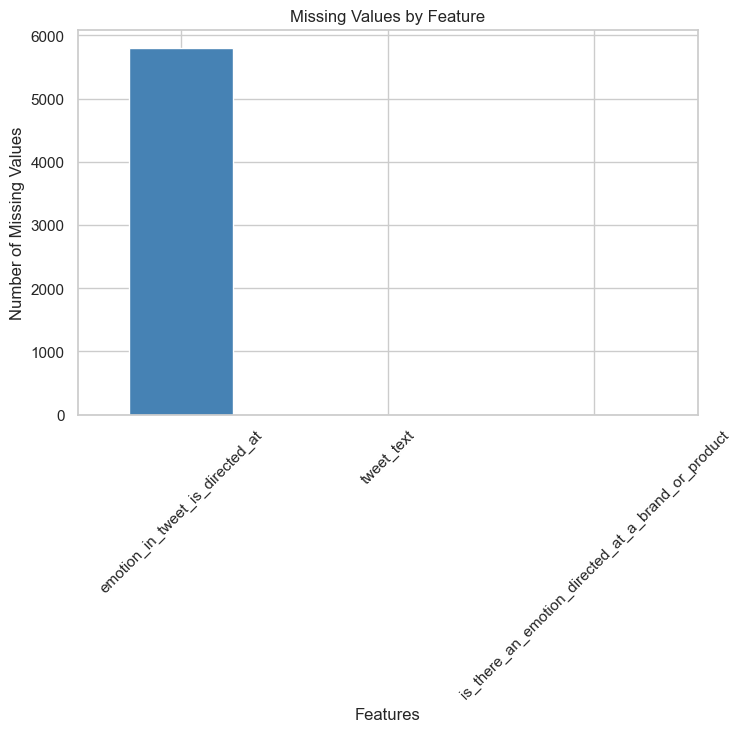

In [19]:
# Visualize missing values

plt.figure(figsize=(8,5))

missing_values.sort_values(ascending=False).plot(
    kind='bar',
    color='steelblue'
)

plt.title('Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')

plt.xticks(rotation=45)

plt.show()

The visualization highlights that the majority of missing values occur in the product-related feature, while the tweet text and sentiment label fields contain little to no missing data.

Since sentiment labels represent the target variable, missing values in this field would significantly reduce the dataset's usefulness for supervised learning. Missing product information may affect product-level analysis but is less critical for sentiment classification because tweet text remains the primary predictor.

### 2.3.2 Dulplicates

Duplicate observations can bias model training and inflate performance metrics if not identified and addressed.

In [23]:
# Check for duplicate records

duplicates = df.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 22


Duplicate tweets may cause the model to learn repetitive patterns that do not accurately represent real-world customer sentiment. Removing duplicates helps improve the reliability of the analysis.

### 2.3.3 Data Type
Verifying data types ensures that each variable is stored in an appropriate format for analysis and modeling.

In [ ]:
# data types

df.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

All variables are currently stored as object (string) data types, which is expected because the dataset consists primarily of textual information.

### 2.3.4 Data Quality Summary

The data quality assessment revealed several important observations:

(i) The dataset contains 9,093 tweets.

(ii) The sentiment label column contains no missing values, making it suitable for supervised learning.

(iii) The product-related feature contains a substantial number of missing values.

(iv) The tweet text feature contains very few missing observations.

(v) Duplicate records may exist and should be addressed during data cleaning.

(vi) All variables are stored as text-based features.

**Implications for the Project**

The dataset remains highly suitable for sentiment classification because the target variable is complete and the tweet text field is largely intact.

The primary data quality challenge involves missing product information. However, since the objective of the project is to classify sentiment based on tweet content, this issue is not expected to significantly impact model performance.

## 2.3.5 Dataset Limitations

The dataset is useful for a proof-of-concept NLP sentiment classifier, but it has limitations:

 **Class imbalance:** Negative and unclear tweets are much less common than neutral/no-emotion tweets.

 **Missing product labels:** Many tweets do not specify the product or brand they are directed at.

 **Historical Twitter data:** Language patterns may differ from current social media behavior.

 **Human labeling subjectivity:** Sentiment labels depend on human raters and may include ambiguity.
 
 **Short text complexity:** Tweets are brief and may contain sarcasm, abbreviations, hashtags, and informal language.

# 3. Data Cleaning 
The purpose of data cleaning is to improve data quality by addressing missing values, duplicate records, and inconsistencies in the text data. Since machine learning models rely heavily on data quality, cleaning the dataset is an essential step before exploratory analysis and model development.

**Data Quality Issues Identified**

The Data Understanding phase identified the following issues:

(i) Missing values in the product feature

(ii) Missing values in tweet text

(iii) Duplicate records

(iv) Unstructured tweet text

(v) Inconsistent text formatting

These issues will be addressed in this section.

# 3.1 Renaming Columns
Long column names can make code difficult to read and maintain. Renaming columns to concise and descriptive names improves readability and simplifies analysis throughout the project.

In [46]:
# Rename columns

df.rename(
    columns={
        'tweet_text': 'tweet',
        'emotion_in_tweet_is_directed_at': 'product',
        'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
    },
    inplace=True
)

# Verify changes
df.head()

,tweet,product,sentiment,sentiment
0,i have a g iphone after hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw,iPhone,Negative emotion,Negative
1,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw,iPad or iPhone App,Positive emotion,Positive
2,can not wait for ipad also they should sale them down at sxsw,iPad,Positive emotion,Positive
3,i hope this years festival isnt as crashy as this years iphone app sxsw,iPad or iPhone App,Negative emotion,Negative
4,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress,Google,Positive emotion,Positive


## 3.2 Missing Values Treatment

Identified missing Tweet text and Missing product information in the data understanding phase. Cleaning the missing values as they can reduce data quality and may affect analysis and modeling results.

### 3.2.1 Handling Missing Tweet Text
Tweet text serves as the primary predictor variable. Records without tweet text cannot contribute meaningful information to the sentiment classification task.

In [47]:
# Remove rows with missing tweet text

df = df.dropna(subset=['tweet'])

**verification**

In [49]:
# Verify removal

df['tweet'].isnull().sum()

np.int64(0)

Rows containing missing tweet text have been removed from the dataset.

### 3.2.2 Handling Missing Product Information
A large number of observations contain missing product information. Removing these observations would result in unnecessary loss of potentially valuable sentiment information.
Missing values will be replaced with the category "Unknown".

In [50]:
# Replace missing product values

df['product'] = (
    df['product']
    .fillna('Unknown')
)

**Verification**

In [51]:
# Verify replacement

df['product'].isnull().sum()

np.int64(0)

All missing product information has been replaced with the label "Unknown".

## 3.3 Duplicate Record Treatment
Duplicate rows can overrepresent repeated tweets and bias model training.

### 3.3.1 Removing Duplicate Records


In [52]:
# Remove duplicate records

df = df.drop_duplicates()

**Verification**

In [53]:
# Verify duplicates removed

df.duplicated().sum()

np.int64(0)

Duplicate observations have been successfully removed. Removing duplicates ensures that the analysis reflects unique customer opinions rather than repeated observations.

## 3.4 Text Standardization
Tweet text often contains inconsistent formatting that can create unnecessary variation during analysis. Standardizing text improves consistency and prepares the data for downstream NLP preprocessing.

### 3.4.1 Converting Tweet Text to Lowercase
This ensures same words are interparted consistently.

In [56]:
# Convert text to lowercase

df.loc[:, 'tweet'] = df['tweet'].str.lower()

### 3.4.2 Removing URLs
URLs generally do not contribute meaningful sentiment information.

In [58]:
import re

# Remove URLs

df.loc [:, 'tweet'] = df['tweet'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', str(x))
)

Removing URLs reduces noise while preserving sentiment-related content.

### 3.4.3 Removing Twitter Mentions
User mentions do not contribute useful information for sentiment analysis.

In [59]:
# Remove mentions

df.loc[:, 'tweet'] = df['tweet'].apply(
    lambda x: re.sub(r'@\w+', '', str(x))
)

### 3.4.4 Removing Punctuation
Punctuation can introduce unnecessary variation into textual data.

In [61]:
import string

# Remove punctuation

df.loc[:, 'tweet'] = df['tweet'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

### 3.4.5 Removing Numbers
Most numerical values do not directly contribute to sentiment detection.

In [63]:
# Remove numbers

df.loc[:,'tweet'] = df['tweet'].apply(
    lambda x: re.sub(r'\d+', '', str(x))
)

### 3.4.6 Removing Extra Whitespace
Purpose

Extra spaces can create inconsistencies within textual data.

In [64]:
# Remove extra whitespace

df.loc[:,'tweet'] = df['tweet'].apply(
    lambda x: ' '.join(x.split())
)

### 3.4.7 Standardize Sentiment Labels
Consistent target labels make modeling and interpretation easier.

In [78]:
# Create an independent copy of the dataframe
df = df.copy()
sentiment_mapping = {
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Unclear'
}

df['sentiment'] = df['sentiment'].replace(sentiment_mapping)

df['sentiment'].value_counts()

sentiment
Neutral     5265
Positive    2935
Negative     565
Unclear      156
Name: count, dtype: int64

Standardized labels improve readability and make it easier for stakeholders to interpret visualizations, model outputs, and business recommendations.

## 3.5 Data Cleaning Summary

The data cleaning process was conducted to improve data quality, consistency, and suitability for analysis and machine learning. Several issues identified during the Data Understanding phase were addressed through a systematic cleaning approach.

**The following data cleaning steps were completed:**

(i) Renamed columns to shorter and more descriptive names (tweet, product, and sentiment) to improve code readability and maintainability.

(ii) Standardized sentiment labels into four consistent categories: Positive, Negative, Neutral, and Unclear.

(iii) Removed observations with missing tweet text, as they contained no information useful for sentiment classification.

(iv) Replaced missing product information with "Unknown" to preserve valuable sentiment data while maintaining transparency regarding missing values.

(v) Identified and removed duplicate records to ensure each observation represented a unique customer opinion.

(vi) Standardized tweet text by:
Converting all text to lowercase,
Removing URLs,
removing Twitter user mentions,
removing punctuation,
removing numerical values and 
removing extra whitespace.

These cleaning steps reduced noise, improved data consistency, and enhanced the overall quality of the dataset. The resulting dataset is more suitable for exploratory analysis and machine learning while preserving the information necessary to answer the project's business questions.

# 4. Exploratory Data Analysis (EDA)
The purpose of Exploratory Data Analysis (EDA) is to uncover patterns, trends, and relationships within the dataset that can help answer the project's business questions.

By exploring the distribution of sentiment, product discussions, and tweet characteristics, we can gain a deeper understanding of customer perceptions toward Apple and Google products. These insights will also guide feature engineering and model development in later stages of the project.

## 4.1 Target Variable Analysis.
This section seeks to answer the Business Question 1 in regards to What overall sentiment are customers expressing toward Apple and Google products on Twitter.

### 4.1.1 Sentiment Class Distribution
Understanding the distribution of the target variable and examining sentiment frequencies provides an initial understanding of overall customer sentiment and helps identify potential class imbalance issues.

The code below calculates the frequency of each sentiment category.

In [81]:
# Display sentiment distribution

df['sentiment'].value_counts()

sentiment
Neutral     5265
Positive    2935
Negative     565
Unclear      156
Name: count, dtype: int64

C:\Users\byego\AppData\Local\Temp\ipykernel_4128\139046104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


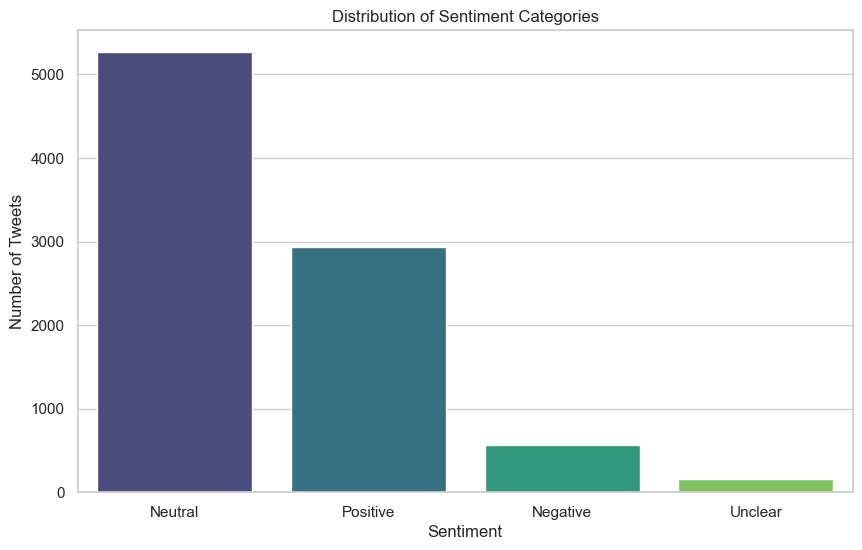

In [82]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='sentiment',
    order=df['sentiment'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.show()

The dataset contains four sentiment categories with varying frequencies. The majority of tweets are classified as Neutral (5,265 tweets), followed by Positive sentiment (2,935 tweets). Negative sentiment represents a much smaller proportion of the dataset (565 tweets), while Unclear sentiment is the least represented category (156 tweets).

**Insights**
The dominance of neutral tweets suggests that many customer conversations are informational rather than emotional. Among tweets expressing sentiment, positive opinions are considerably more common than negative ones, indicating generally favorable perceptions of Apple and Google products within this dataset.

For marketing and brand management teams, this suggests that public sentiment is largely neutral-to-positive, although the presence of negative sentiment highlights opportunities to identify customer concerns and improve user experiences.

### 4.1.2 Sentiment Proportions
While frequency counts show the number of observations, percentage distributions provide a clearer understanding of the relative contribution of each sentiment category.

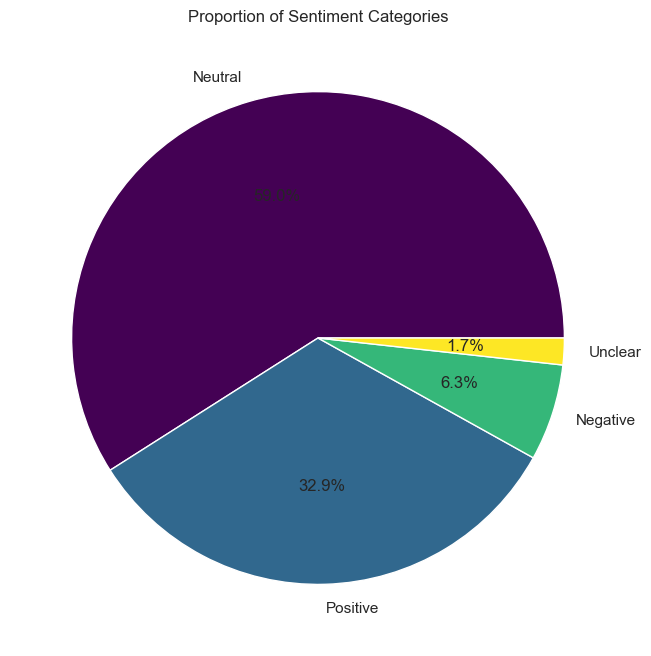

In [143]:
# Get sentiment counts
counts = df['sentiment'].value_counts()

# Generate viridis colors
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(8, 8))

counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)

plt.title('Proportion of Sentiment Categories')
plt.ylabel('')

plt.show()

The pie chart shows that Neutral sentiment accounts for 59.0% of all tweets, making it the dominant sentiment category. Positive sentiment represents 32.9% of tweets, while Negative sentiment accounts for only 6.3%. The Unclear category contributes just 1.7% of observations.

**Insights**

For stakeholders, this finding suggests that customer sentiment is largely positive; however, the smaller negative segment remains important because it may reveal product issues, customer frustrations, or areas for improvement that could impact customer satisfaction and brand reputation.

### 4.1.3 Class Imbalance Assessment

The sentiment distribution reveals a clear class imbalance within the dataset. Neutral tweets account for approximately 59% of all observations, while Positive tweets represent 32.9%. In contrast, Negative and Unclear tweets make up only 6.3% and 1.7% of the dataset, respectively.

This means that the majority of observations belong to the Neutral and Positive classes, while Negative and Unclear sentiments are significantly underrepresented.

In an imbalanced dataset, a model may achieve high accuracy simply by predicting the majority classes more frequently. As a result, accuracy alone may provide a misleading assessment of model performance.

**Insights**

From a business perspective, correctly identifying Negative sentiment is particularly important because negative customer experiences often highlight product issues, dissatisfaction, or areas requiring immediate attention. Although Negative tweets represent a small proportion of the dataset, they may contain some of the most actionable insights for marketing and customer experience teams.

**Implications for Modeling**

To account for the observed class imbalance, Weighted F1-Score will be used as the primary evaluation metric. Unlike accuracy, Weighted F1-Score considers both precision and recall while accounting for the distribution of sentiment classes, providing a more balanced assessment of model performance.


## 4.2 Univariate Analysis

Having explored the target variable and established the overall sentiment distribution, the next step is to examine individual variables within the dataset. Understanding these variables independently provides valuable context for customer conversations and helps uncover patterns that may influence sentiment classification. 

In the context of this project, univariate analysis will be used to explore key variables such as product mentions and tweet characteristics. Understanding these variables individually will help provide context for customer conversations and support the development of effective sentiment classification models.

### 4.2.1 Product Distribution

This is where we begin answering which products the customers are discussing frequently.

In [86]:
# Top product mentions

df['product'].value_counts().head(15)

product
Unknown                            5678
iPad                                936
Apple                               648
iPad or iPhone App                  462
Google                              425
iPhone                              295
Other Google product or service     289
Android                              77
Android App                          76
Other Apple product or service       35
Name: count, dtype: int64

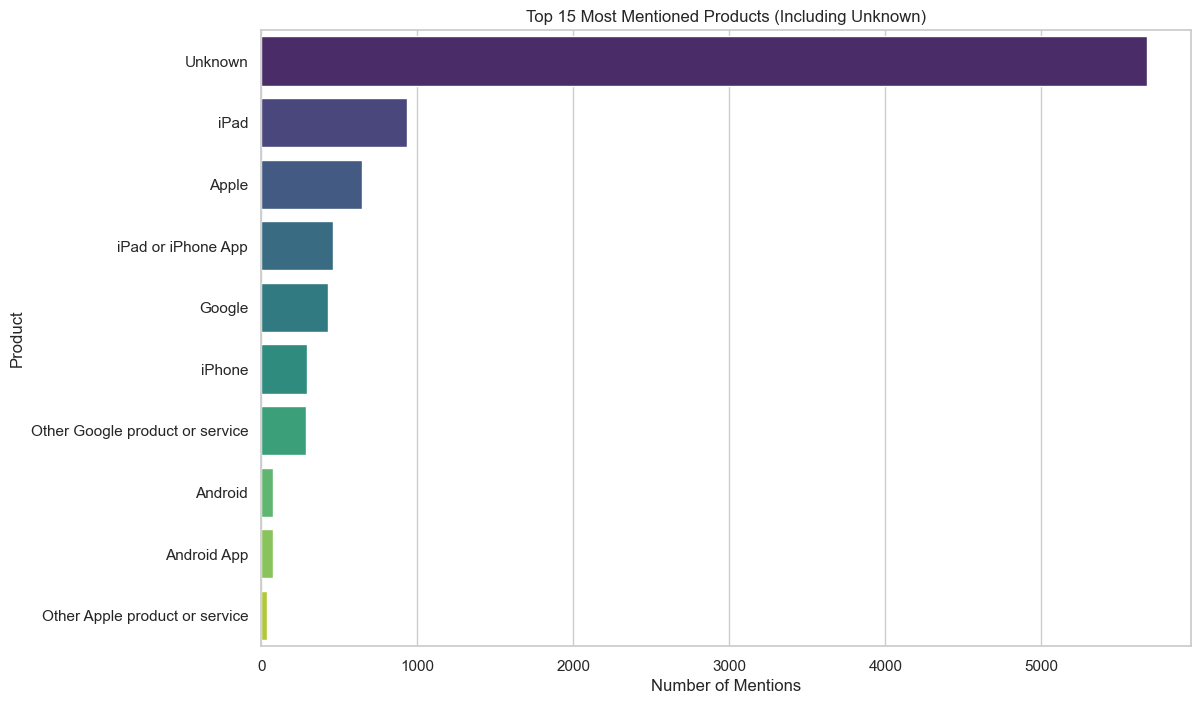

In [107]:
product_counts = df['product'].value_counts().head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    x=product_counts.values,
    y=product_counts.index,
    hue=product_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Top 15 Most Mentioned Products (Including Unknown)')
plt.xlabel('Number of Mentions')
plt.ylabel('Product')

plt.show()

**Analysis 1 inlcudes The "Unknown" product category.** 


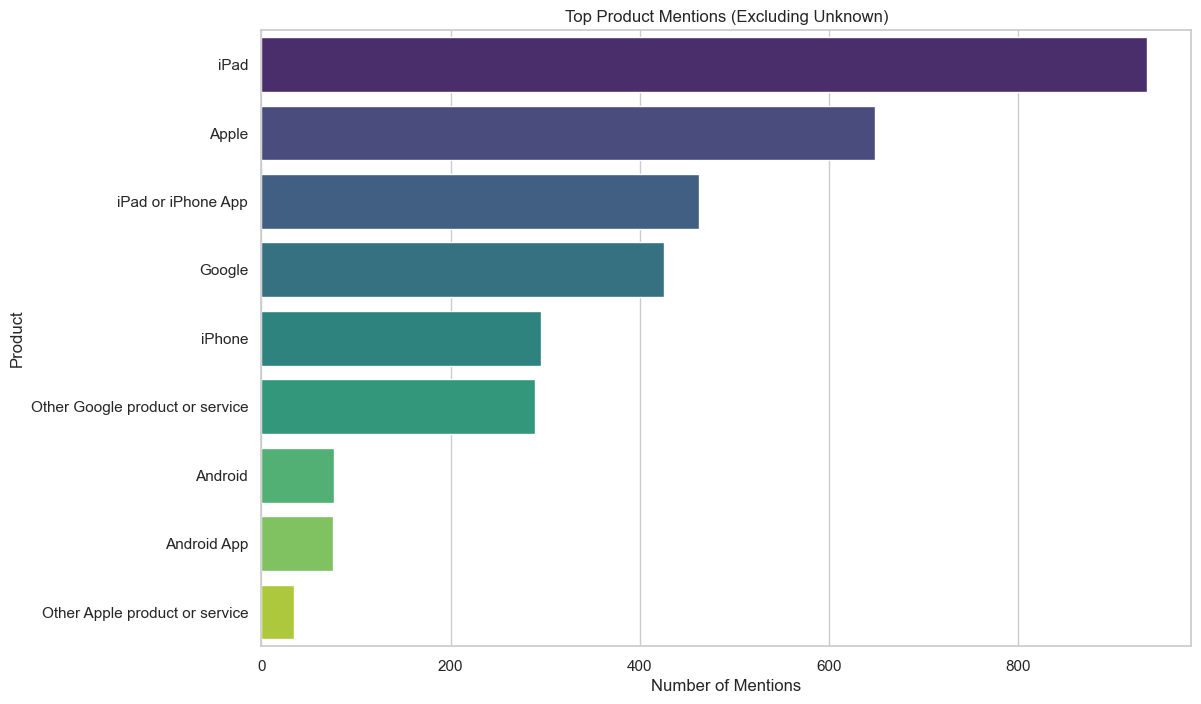

In [91]:
# Product distribution excluding Unknown

product_counts = (
    df[df['product'] != 'Unknown']['product']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=product_counts.values,
    y=product_counts.index,
    hue=product_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Top Product Mentions (Excluding Unknown)')
plt.xlabel('Number of Mentions')
plt.ylabel('Product')

plt.show()

**Analysis 2 excludes The "Unknown" product category.** 

The product distribution reveals that a substantial number of tweets are categorized as Unknown, indicating that many observations do not explicitly identify a specific Apple or Google product.

Among tweets with identifiable products, the iPad is the most frequently discussed product, followed by Apple, iPad or iPhone App, Google, and iPhone. Android-related products appear less frequently in the dataset.

**Insights**

The high number of unknown product references suggests that customers often discuss brands or experiences without explicitly mentioning a specific product. This highlights the importance of analyzing tweet content directly rather than relying solely on product identifiers.

Among identifiable products, Apple-related products appear more frequently than Google-related products, suggesting that Apple products generated a larger share of customer conversations within this dataset.


### 4.2.2 Tweet Length Distribution

Tweet length can influence sentiment classification performance because longer tweets often contain more contextual information than shorter tweets.Understanding the distribution of tweet lengths helps identify common communication patterns and informs feature engineering decisions later in the project.

In [93]:
# Create tweet length feature

df['tweet_length'] = df['tweet'].apply(len)

# Preview
df[['tweet', 'tweet_length']].head()

,tweet,tweet_length
0,i have a g iphone after hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw,104
1,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw,112
2,can not wait for ipad also they should sale them down at sxsw,61
3,i hope this years festival isnt as crashy as this years iphone app sxsw,71
4,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress,107


In [94]:
# Summary statistics

df['tweet_length'].describe()

count    8921.000000
mean       90.055935
std        25.142043
min         2.000000
25%        72.000000
50%        92.000000
75%       110.000000
max       152.000000
Name: tweet_length, dtype: float64

The average tweet length is approximately 90 characters, with a median of 92 characters, indicating a fairly balanced distribution. Most tweets fall between 72 and 110 characters, suggesting that users typically express their opinions through short, concise messages. While a few tweets are extremely short or approach the character limit, tweet lengths are generally consistent across the dataset.

**Tweet Length Distribution**

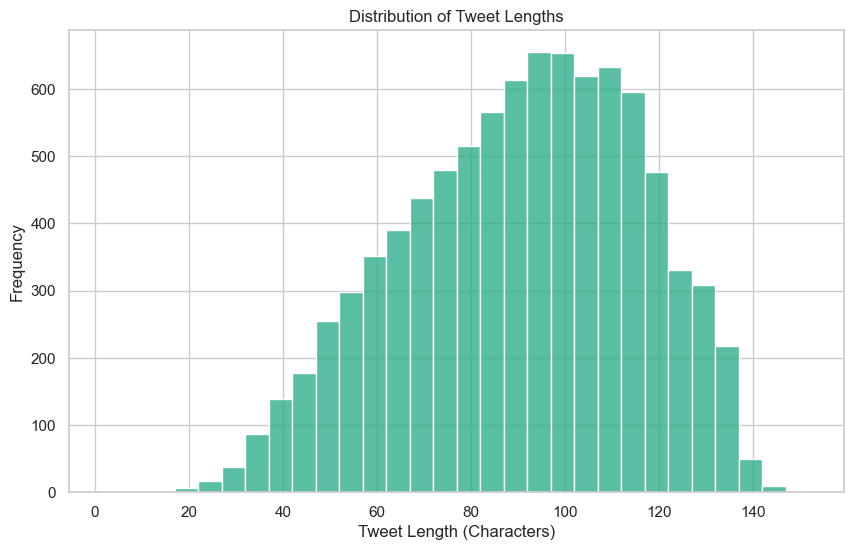

In [99]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tweet_length',
    bins=30,
    color = plt.cm.viridis(0.6)
)

plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length (Characters)')
plt.ylabel('Frequency')

plt.show()

The distribution of tweet lengths appears approximately bell-shaped, with most tweets ranging between 70 and 120 characters. The highest concentration of tweets falls around 90–110 characters, which aligns closely with the mean and median tweet lengths observed earlier. Very short and very long tweets are relatively uncommon.

The distribution does not appear heavily skewed and shows no evidence of excessive outliers, suggesting that tweet length is relatively consistent across observations and unlikely to require additional transformation prior to modeling.

### 4.2.3 Word Count Distribution

Word count measures the actual amount of language used by customers, making it particularly relevant for sentiment analysis.The purpose of this analysis is to examine the number of words used in customer tweets. Word count provides insight into the amount of information contained within each tweet and may influence how sentiment is expressed.

Understanding word count patterns can also help identify whether customers typically communicate through short reactions or more detailed opinions.

**Number of words contained in each tweet**

In [109]:
# Create word count feature

df['word_count'] = df['tweet'].apply(
    lambda x: len(str(x).split())
)

# Preview
df[['tweet', 'word_count']].head()

,tweet,word_count
0,i have a g iphone after hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw,21
1,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw,19
2,can not wait for ipad also they should sale them down at sxsw,13
3,i hope this years festival isnt as crashy as this years iphone app sxsw,14
4,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress,16


**Summary statistics**

In [111]:
# Summary statistics

df['word_count'].describe()

count    8921.000000
mean       16.549378
std         4.767445
min         1.000000
25%        13.000000
50%        17.000000
75%        20.000000
max        30.000000
Name: word_count, dtype: float64

The average tweet contains approximately 17 words, with a median of 17 words, indicating a relatively balanced distribution. Most tweets contain between 13 and 20 words, while very short and very long tweets are uncommon. The maximum word count of 30 suggests that even the longest tweets remain relatively concise.

**Word count boxplot**

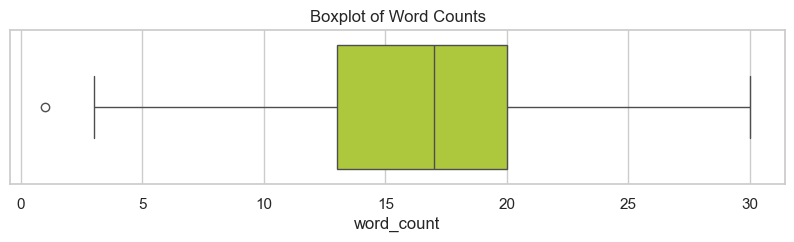

In [119]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['word_count'],
    color=plt.cm.viridis(0.9)
)

plt.title('Boxplot of Word Counts')

plt.show()

The boxplot shows that the majority of tweets contain between 13 and 20 words, with a median word count of approximately 17 words. The distribution appears relatively symmetrical, with limited variability and few extreme values. A small number of very short tweets are identified as outliers, while no substantial high-end outliers are observed.

**Insights**

The relatively narrow spread of word counts suggests that customers communicate their opinions in a consistent and concise manner. The absence of extreme outliers indicates that most tweets provide a similar amount of textual information, which can help improve the consistency and reliability of sentiment classification models.

### 4.2.4 Most Frequent Words Analysis
The purpose of this analysis is to identify the most commonly used words within the tweet dataset. Examining word frequencies helps uncover dominant discussion topics, recurring themes, and commonly referenced products or brands.

This analysis provides valuable context for understanding customer conversations and may reveal words that contribute significantly to sentiment classification.

### Creating a Corpus of Words
The code below combines all tweets into a single text corpus and calculates the frequency of each word.

In [146]:


# Define stopwords
stop_words = set(stopwords.words('english'))

#project-specific stopwords
custom_stopwords = {
    'rt', 'amp', 'quot', 'im', 'dont', 'cant', 'youre',
    'apple', 'google'
}

all_stopwords = stop_words.union(custom_stopwords)

# Create cleaned word list from tweet column
filtered_words = []

for tweet in df['tweet']:
    words = str(tweet).split()
    for word in words:
        word = word.lower().strip()
        if word not in all_stopwords and len(word) > 2:
            filtered_words.append(word)

# Count filtered words
word_freq = Counter(filtered_words)

# Create top words dataframe
top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,sxsw,9281
1,link,4164
2,ipad,2828
3,iphone,1497
4,store,1442
5,new,1037
6,austin,932
7,app,786
8,social,598
9,launch,597


**Visualizing most frequent words**

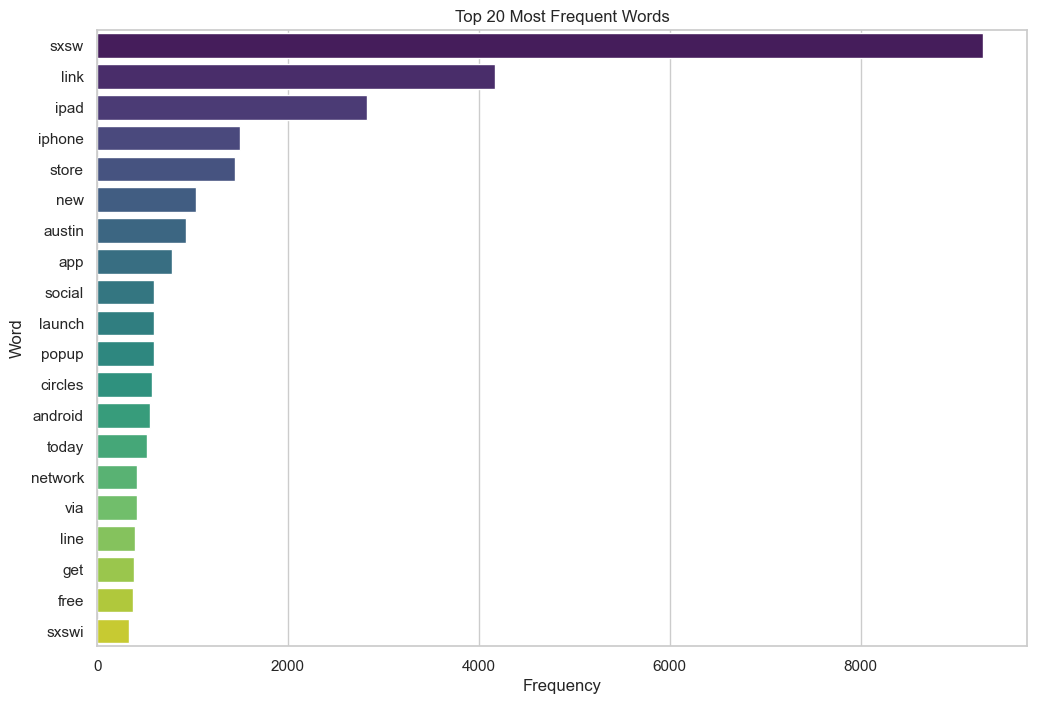

In [147]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='viridis',
    legend=False
)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

**Insights**

The frequency analysis suggests that much of the conversation surrounding Apple and Google products occurred within the context of a major technology event. This highlights how industry conferences and product launches can significantly influence online discussions and customer engagement.

The prominence of product-specific terms such as iPad, iPhone, and Android indicates that these products generated substantial attention and may play an important role in shaping overall sentiment toward the brands.

The presence of event-specific terms such as SXSW highlights the importance of context when interpreting word frequencies. Not all commonly occurring words directly reflect customer sentiment; some capture the broader environment in which conversations took place.

### 4.2.5 Word Cloud Analysis

Word clouds help visualize the most prominent terms appearing in tweets and provide a quick overview of dominant discussion themes.

#### 4.2.5.1 Overall Word Cloud
The purpose of the overall word cloud is to visualize the most frequently occurring words across all tweets. Larger words represent terms that appear more frequently within customer conversations.

The code below combines all tweets into a single text corpus and generates a word cloud using the Viridis color palette.

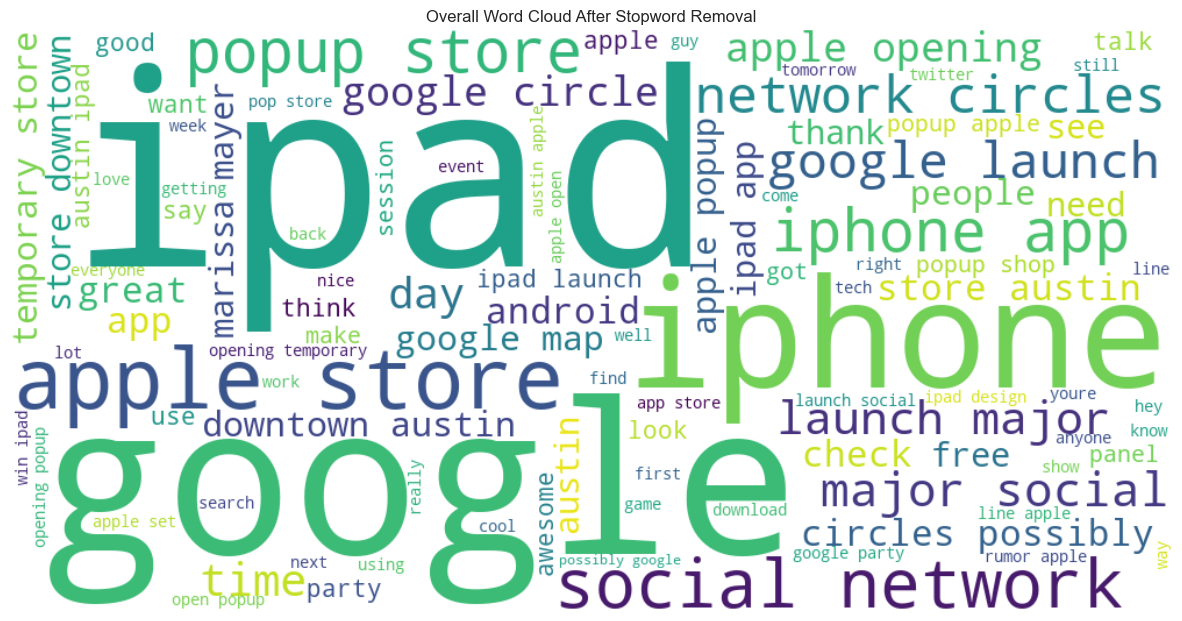

In [159]:


# Define custom stopwords
custom_stopwords = {
    'sxsw', 'sxswi', 'link', 'rt', 'amp',
    'via', 'new', 'one', 'will', 'now',
    'today', 'get', 'going', 'called',
    'ûï', 'ûò', 'ûª', 'û', 'å'
}

# Combine default WordCloud stopwords with custom stopwords
all_stopwords = set(STOPWORDS).union(custom_stopwords)

# Create one text corpus
all_text = ' '.join(df['tweet'].astype(str))

# Remove non-letter characters and lowercase text
all_text_clean = re.sub(r'[^a-zA-Z\s]', ' ', all_text).lower()

# Split text into words and manually remove stopwords
filtered_words = [
    word for word in all_text_clean.split()
    if word not in all_stopwords and len(word) > 2
]

# Rejoin filtered words into clean text
filtered_text = ' '.join(filtered_words)

# Generate word cloud from filtered text
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(filtered_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud After Stopword Removal')
plt.show()

**Insights**

The overall word cloud highlights the most frequently discussed topics within customer conversations. Prominent terms such as Google, Apple, iPad, iPhone, App, and Store indicate that discussions were heavily centered around mobile devices, applications, and digital services.

The appearance of terms such as Launch, Social Network, Google Circle, and Popup Store suggests that many conversations focused on product announcements, technology events, and emerging digital platforms.

#### 4.2.5.2 Positive Sentiment Word Cloud
This analysis helps to identify the words most frequently associated with positive sentiment. Understanding these terms helps reveal the features, products, and experiences that customers view favorably.

The code below filters tweets classified as Positive, removes common and project-specific stopwords, and generates a word cloud highlighting the most prominent positive terms.

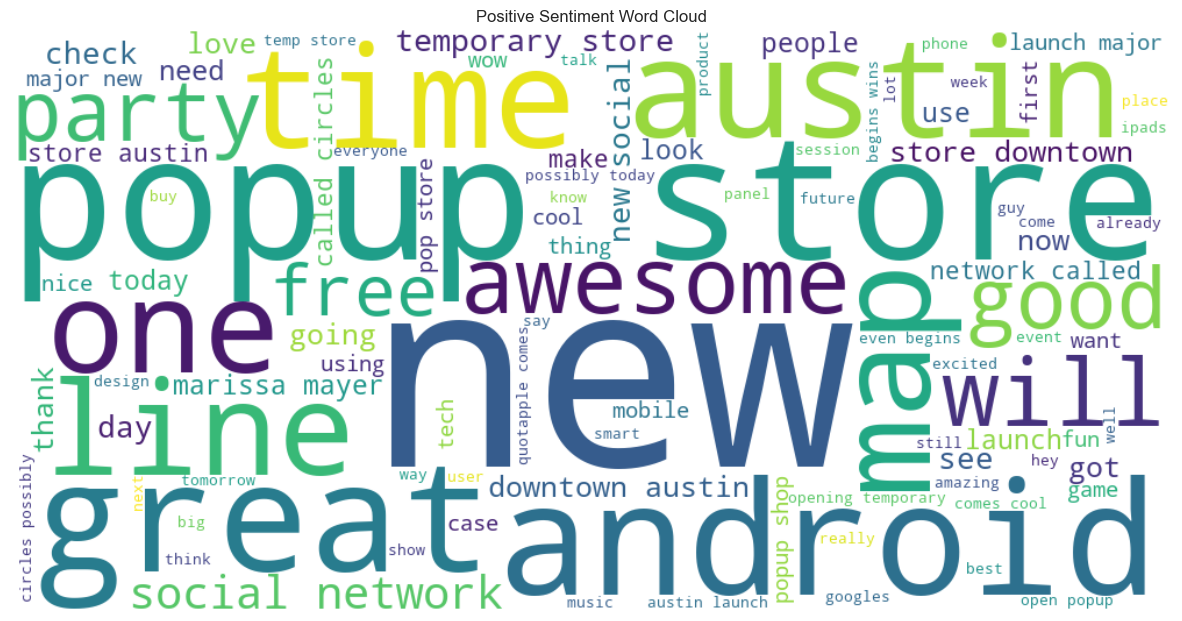

In [160]:

# Extract positive tweets
positive_text = ' '.join(
    df[df['sentiment'] == 'Positive']['tweet'].astype(str)
)

# Additional stopwords
positive_stopwords = set(STOPWORDS).union({
    'google', 'apple', 'ipad', 'iphone',
    'app', 'apps', 'sxsw', 'sxswi',
    'link', 'rt', 'amp', 'via'
})

# Clean text
positive_text = re.sub(r'[^a-zA-Z\s]', ' ', positive_text).lower()

# Remove stopwords
filtered_positive = [
    word for word in positive_text.split()
    if word not in positive_stopwords and len(word) > 2
]

positive_text_clean = ' '.join(filtered_positive)

# Generate word cloud
positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(positive_text_clean)

# Plot
plt.figure(figsize=(15,8))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment Word Cloud')
plt.show()

**Insights**

Prominent positive words such as great, awesome, good, love, nice, and fun suggest that many users expressed enthusiasm and satisfaction when discussing Apple and Google products.
The prevalence of strongly positive terms suggests that customers generally viewed their experiences with Apple and Google products favorably. Discussions surrounding applications, stores, social networking features, and product-related events appear to be important drivers of positive engagement.

For stakeholders, this indicates that successful product launches, innovative features, and engaging user experiences may contribute significantly to positive public sentiment.

#### 4.2.5.3 Negative Sentiment Word Cloud
This anallsis identifies the words most frequently associated with negative sentiment. Understanding these terms can help uncover customer frustrations, product concerns, and areas where improvements may be needed.

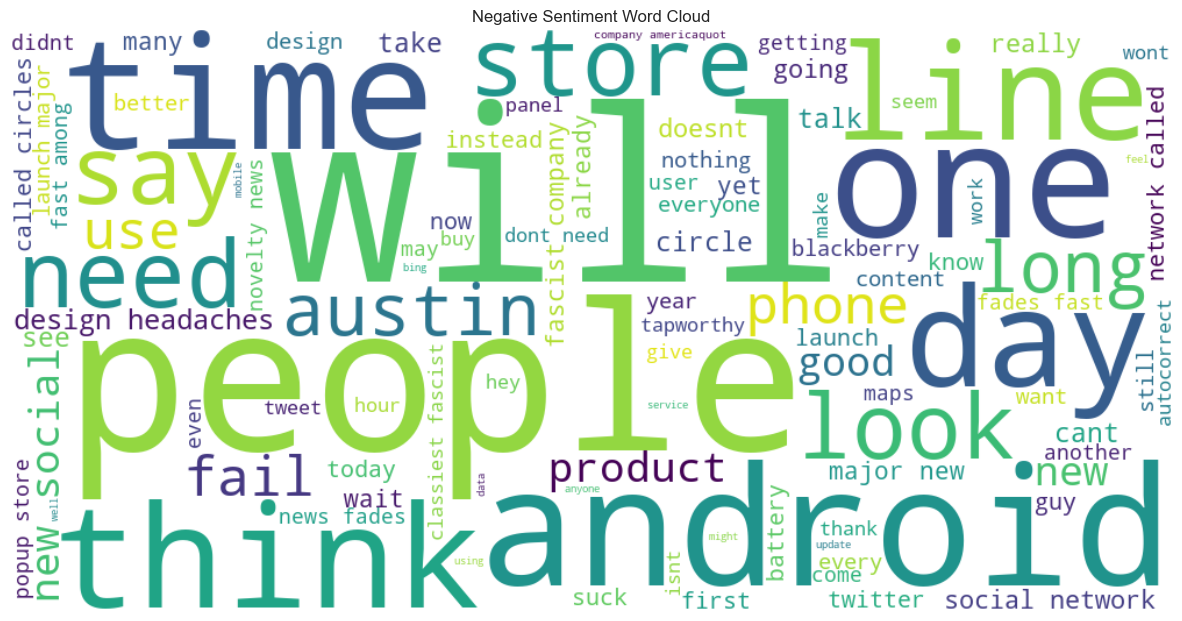

In [162]:
# Extract negative tweets

negative_text = ' '.join(
    df[df['sentiment'] == 'Negative']['tweet'].astype(str)
)

# Additional stopwords

negative_stopwords = set(STOPWORDS).union({
    'google', 'apple', 'ipad', 'iphone',
    'app', 'apps', 'sxsw', 'sxswi',
    'link', 'rt', 'amp', 'via'
})

# Clean text

negative_text = re.sub(r'[^a-zA-Z\s]', ' ', negative_text).lower()

# Remove stopwords

filtered_negative = [
    word for word in negative_text.split()
    if word not in negative_stopwords and len(word) > 2
]

negative_text_clean = ' '.join(filtered_negative)

# Generate word cloud

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(negative_text_clean)

# Plot

plt.figure(figsize=(15,8))

plt.imshow(negative_wc, interpolation='bilinear')

plt.axis('off')

plt.title('Negative Sentiment Word Cloud')

plt.show()

Prominent words such as fail, headaches, battery, can't, doesn't, and fades suggest that users expressed concerns related to product performance, functionality, and user experience.The appearance of terms such as product, design, network, and social indicates that negative sentiment was often linked to product features, service reliability, and technology-related experiences.

**Insights**

The negative sentiment vocabulary suggests that customer dissatisfaction is primarily driven by usability issues, product performance concerns, and unmet expectations. Terms related to battery performance, technical failures, and functionality challenges highlight areas that may require further investigation by product and customer experience teams.

For stakeholders, monitoring these recurring concerns can help identify opportunities to improve product quality and customer satisfaction


### 4.3 Bivariate Analysis

Bivariate analysis explores relationships between two variables. This analysis helps uncover patterns that may influence customer sentiment and provides deeper insights into how product discussions and tweet characteristics relate to sentiment outcomes.

The findings from this section will help answer key business questions and guide feature engineering and model development.

#### 4.3.1 Sentiment by Product
Understanding how sentiment varies across products helps identify which Apple and Google products generate the most favorable and unfavorable customer reactions.

The code below creates a cross-tabulation showing the distribution of sentiment categories across products.

In [164]:
# Sentiment distribution by product

sentiment_product = pd.crosstab(
    df['product'],
    df['sentiment']
)

sentiment_product.head()

sentiment,Negative,Neutral,Positive,Unclear
product,,,,
Android,8,1,68,0
Android App,8,1,67,0
Apple,95,21,530,2
Google,68,15,341,1
Other Apple product or service,2,1,32,0


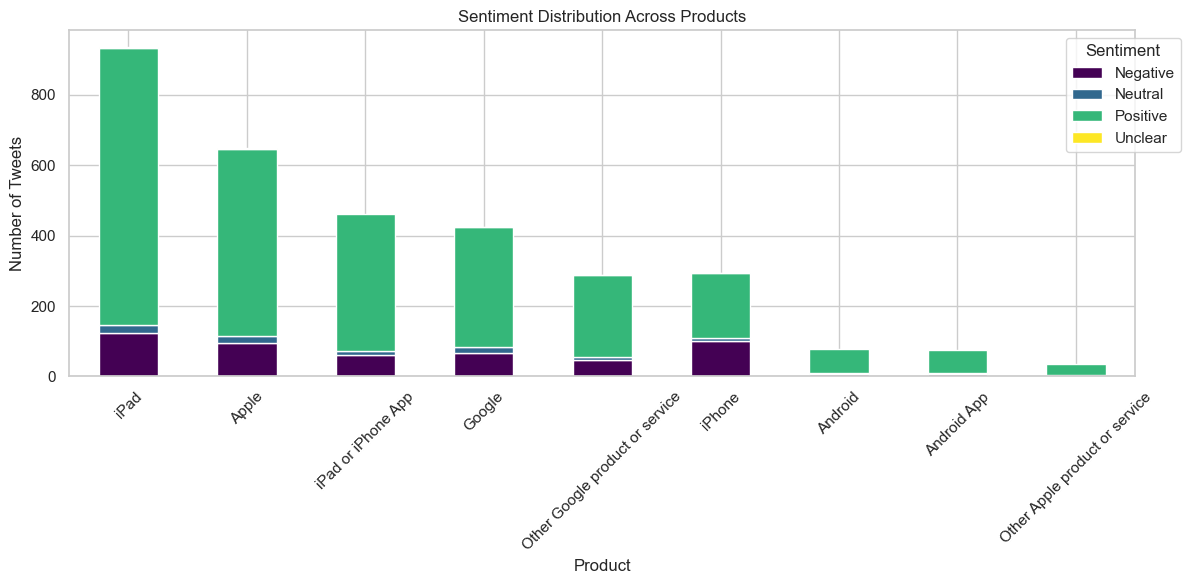

In [169]:
# Exclude Unknown products

filtered_df = df[df['product'] != 'Unknown']

sentiment_product = pd.crosstab(
    filtered_df['product'],
    filtered_df['sentiment']
)

sentiment_product.sort_values(
    by='Positive',
    ascending=False
).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title('Sentiment Distribution Across Products')
plt.xlabel('Product')
plt.ylabel('Number of Tweets')

plt.xticks(rotation=45)

plt.legend(
    title='Sentiment',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

**Insights**

The visualization shows that positive sentiment is the dominant sentiment category across all products. The highest volume of sentiment is associated with iPad, followed by Apple, iPad or iPhone App, Google, and iPhone. While negative sentiment is present across several products, it represents a much smaller proportion of overall conversations.

Among the most frequently discussed products, the iPhone appears to attract a relatively larger share of negative sentiment compared to other products, suggesting potential differences in customer experiences or expectations.

### 4.3.2 Sentiment Composition by Product

While the previous analysis examined the volume of sentiment associated with each product, this analysis investigates the proportion of positive, negative, neutral, and unclear sentiment within each product category. By normalizing sentiment distributions, we can compare products fairly regardless of differences in discussion volume. We shall explore which products receive the highest proportion of positive and negative sentiment

**Sentiment proportions**

In [170]:
# Calculate sentiment percentages by product

sentiment_pct = pd.crosstab(
    filtered_df['product'],
    filtered_df['sentiment'],
    normalize='index'
) * 100

# Display results

sentiment_pct.round(1)

sentiment,Negative,Neutral,Positive,Unclear
product,,,,
Android,10.4,1.3,88.3,0.0
Android App,10.5,1.3,88.2,0.0
Apple,14.7,3.2,81.8,0.3
Google,16.0,3.5,80.2,0.2
Other Apple product or service,5.7,2.9,91.4,0.0
Other Google product or service,16.3,3.1,80.3,0.3
iPad,13.1,2.6,83.9,0.4
iPad or iPhone App,13.4,2.2,84.4,0.0
iPhone,34.2,3.1,62.4,0.3


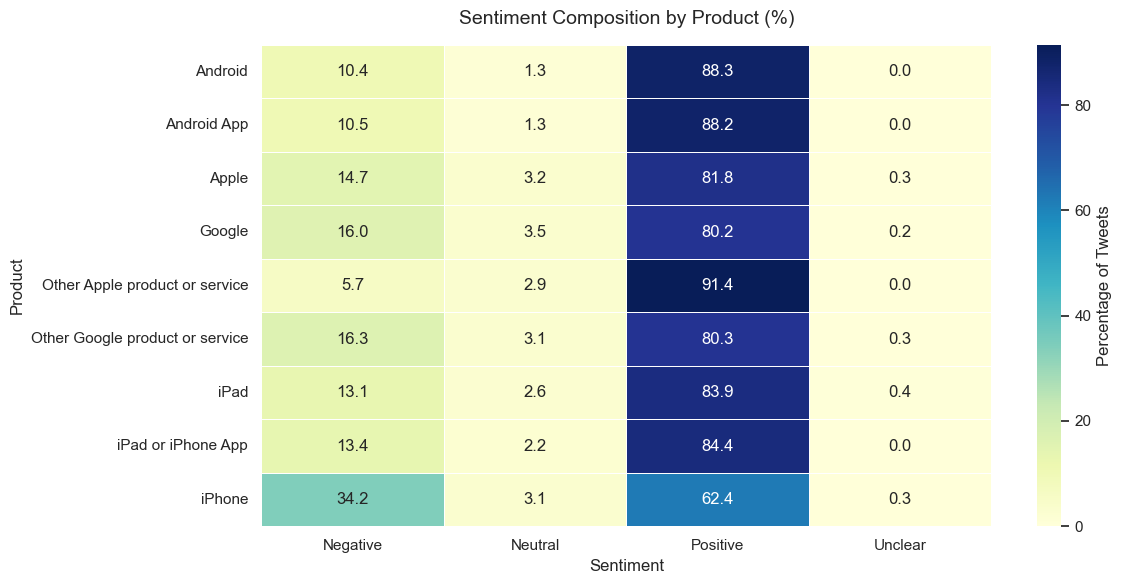

In [174]:
plt.figure(figsize=(12,6))

sns.heatmap(
    sentiment_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Percentage of Tweets'}
)

plt.title(
    'Sentiment Composition by Product (%)',
    fontsize=14,
    pad=15
)

plt.xlabel('Sentiment')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

**Insights**
The heatmap reveals that most Apple and Google products enjoy overwhelmingly positive customer sentiment, suggesting strong brand perception and generally favorable user experiences. Products such as Android, Android App, and iPad or iPhone App demonstrate particularly high positivity rates, indicating that customers respond well to these offerings.

However, the iPhone emerges as a notable exception, exhibiting the highest negative sentiment rate (34.2%) and the lowest positive sentiment rate (62.4%) among all products. This suggests that iPhone users may have higher expectations, encounter more product-related frustrations, or be more vocal about issues compared to users of other products.

For stakeholders, this finding highlights the importance of monitoring customer feedback at the product level rather than relying solely on overall brand sentiment. While overall sentiment toward Apple and Google products is largely positive, product-specific challenges may be hidden within aggregate sentiment metrics.

### 4.3.3 Tweet Length by Sentiment

This analysis investigates whether tweet length varies across sentiment categories. Understanding these differences may provide insights into how customers communicate positive, negative, neutral, and unclear opinions.

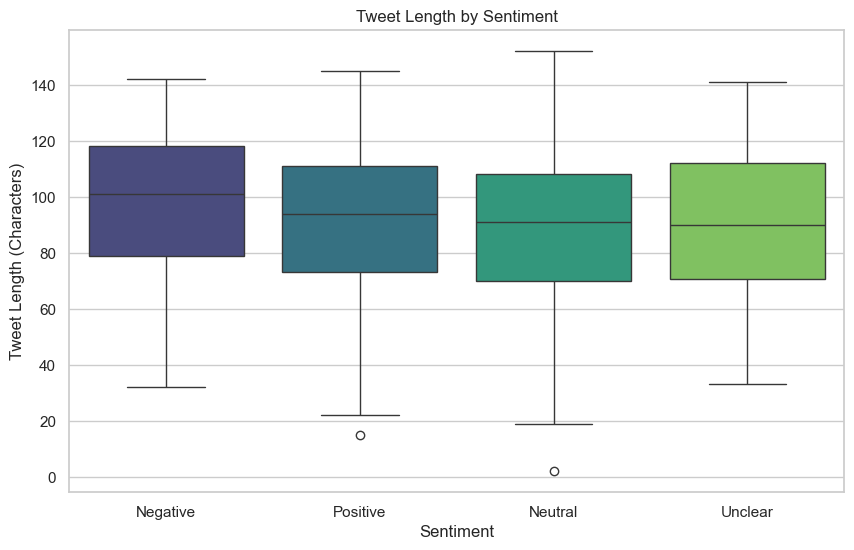

In [175]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='sentiment',
    y='tweet_length',
    hue='sentiment',
    palette='viridis',
    legend=False
)

plt.title('Tweet Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Tweet Length (Characters)')

plt.show()

**Insights**

The boxplot shows that tweet lengths are generally similar across all sentiment categories, with median lengths ranging between approximately 90 and 100 characters. Negative tweets have a slightly higher median length, suggesting that users expressing dissatisfaction may provide more detailed feedback. Overall, the differences are relatively small, indicating that tweet length alone is unlikely to strongly differentiate sentiment categories.

The limited variation in tweet length across sentiment categories suggests that features derived from the actual text content (such as word frequencies, TF-IDF scores, or n-grams) are likely to be more valuable for sentiment classification than simple length-based features.

### 4.3.4 Word Count by Sentiment
The purpose of this analysis is to examine whether the number of words used in a tweet varies across sentiment categories. These differences can provide insight into how customers communicate positive, negative, and neutral opinions.

**Summary Statistics**

In [177]:
df.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Negative,565.0,17.780531,4.936976,5.0,14.00,18.0,21.0,29.0
Neutral,5265.0,16.177398,4.710549,1.0,13.00,16.0,20.0,30.0
Positive,2935.0,16.982964,4.757628,3.0,13.50,17.0,21.0,30.0
Unclear,156.0,16.487179,4.845333,7.0,12.75,17.0,20.0,29.0


The code below compares word count distributions across sentiment categories using a boxplot.

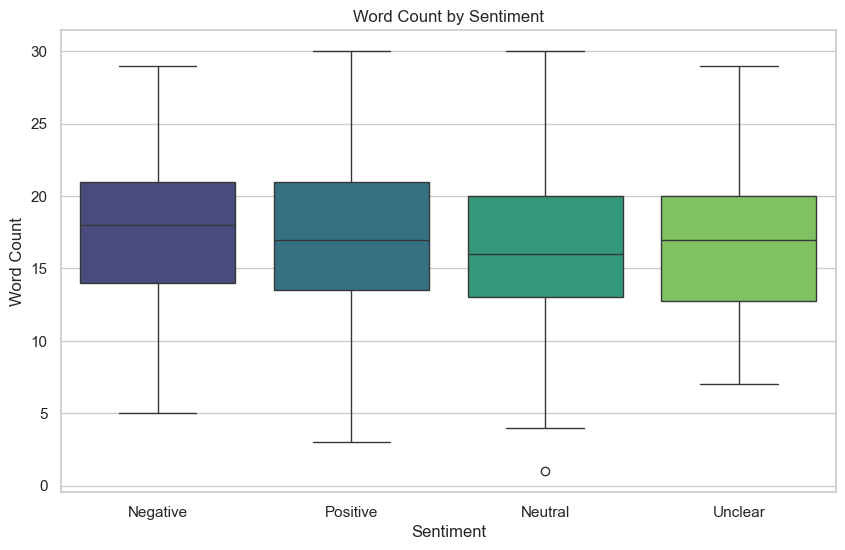

In [176]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='sentiment',
    y='word_count',
    hue='sentiment',
    palette='viridis',
    legend=False
)

plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')

plt.show()

**Insights**

The boxplot shows that word counts are relatively consistent across all sentiment categories, with median word counts ranging from approximately 16 to 18 words. Negative tweets have a slightly higher median word count, while neutral tweets tend to contain slightly fewer words. Overall, the differences are small, suggesting that sentiment is not strongly associated with the number of words used in a tweet. This suggests that the content of the message is likely more important than the quantity of words when determining sentiment.


# 5. Data Preparation